<a href="https://www.kaggle.com/code/isissantoscosta/divvy-dimensional-modeling-conversion-analytics?scriptVersionId=333304146" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<h1 style="font-size: 5rem;">🚧 Work in Progress</h1>

#### <a id='top'></a>
Created: [Apr 02, 2024](https://www.kaggle.com/code/isissantoscosta/google-capstone-bikeshare-quick-analysis) &nbsp;•&nbsp; Updated: Oct 30, 2025 &nbsp;•&nbsp; by [Ísis Santos Costa](https://www.linkedin.com/in/isis-santos-costa/) 👩‍💻🤖 (AI-Augmented)  

<hr>

**« How to turn users into subscribers? »**

This is a question constantly faced by **businesses**, especially **Marketing** and **Product** teams in **SaaS** companies aiming to promote **usage that increases revenue**, particularly measured as annual recurring revenue (**ARR**). This same challenge was proposed as a [**Capstone Project**](https://www.coursera.org/learn/google-data-analytics-capstone/) of the [**Google Data Analytics Professional Certificate**](https://www.coursera.org/professional-certificates/google-data-analytics/) curriculum, which this project addresses.  

---
The data used in this project is available as a Kaggle dataset on [**🚲 Divvy・Chicago Bikeshare Dataset**](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/).

<center>
    <img src='https://raw.githubusercontent.com/isis-santos-costa/isis-santos-costa/refs/heads/main/img/pandas.png' alt='pandas' width='350'>
</center>

<a id='executive_summary'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:left; font-weight:regular; overflow:hidden"><strong>Executive Summary</strong></div>

Cyclistic is a **fictional bikeshare system** that allows users to rent a bike from a station and return it to any other station within the system, catering to both **leisure** and **transportation** needs.  

Their available pricing plans include:  
* Single-ride pass (_casual riders_)
* Full-day pass (_casual riders_)
* Annual membership (_members_ / _subscribers_)

The Finance team reported that **subscribers** are considerably **more profitable** than casual riders. Following that, the Marketing department is focused on increasing the **number of memberships**. Specifically, to leverage the lowest activation energy available, it is designing a strategy to **convert casual riders into subscribers**. This report presents the analysis and recommendations by the **Product Data** team to support the mentioned Marketing initiatives, in light of the insights by the Finance team.  

- **Problem**: Casuals are under-monetized.  
- **Goal**: Turn casual users into subscribers.  
- **Method**: Profile user behavior, identify the ICP (Ideal Customer Profile), score casual users.  
- **Recommendation**: Target high-ICP casual users with offers/campaigns.  
- **Impact**: X% conversion potential → profitability & revenue growth.

---

This document is designed for a Two-Track Navigation:
- **Business Track**: [Exec Summary](#executive_summary) → [Identify the ICP](#icp) → [Find high-ICP casual users](#action) (5-7 min read)
- **Technical Track**: Full project, with [Data Quality](#data_quality), [Modular Design](#modular_design), and analytical discussion (15-20 min read)

<hr>

<a id="contents"></a>
# <strong>Contents</strong>  
[**Executive Summary**](#executive_summary)  
[Step 1 • **Business questions**](#business_questions)  
[Step 2 • **Data collection**](#data_collection)  
[Step 3 • **Data prep**](#data_prep)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [⧗ Load](#loading)    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [⌕ Inspect](#inspecting)    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [𖤘 Type cast](#type_casting)   
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [**✓** Ensure **_Data Quality_**](#data_quality)     
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [🛈 Describe](#describing)    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [⛯ Engineer features](#feature_engineering)    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [🗲 **_Dimensional Modeling_**](#dimensional_modeling)   
[Step 4 • **Analysis**](#analysis)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [⦿ Identify the Ideal Customer Profile (ICP)](#icp)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [◇ Find high-ICP casual users](#high_icp)  
[Step 5 • **Action**](#action)  
[References](#references)  
[Annex: User upgrade strategies](#annex)  
[Takeaways](#takeaways)  

<hr>

<a id='business_questions'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:center; font-weight:regular; overflow:hidden"><strong>Step 1 • Business questions</strong></div>

As mentioned in the [Executive Summary](#executive_summary) above, the **business outcome** targeted in this project is to **increase the number of subscribers**, pointed out by Finance as more profitable than casual users. Seeking clever wins, the Marketing team chooses to start by **converting casual users into subscribers**. 

This leads to the following driving question:

> **How to convert casual users into subscribers?**

<br> 

With a customer-centric perspective added, the query expands into:

> **How do annual members and casual riders use our services differently?**

<br>

The **Product Data** team then unpacks the latter into the following, focusing on operational actionability:

1. **When** do members typically rent a bike versus when do casual users?
2. **How long** are member rides versus casual rides?
3. **Where** do members ride versus where do casual users?

Together, these three questions answer our key business question:
> **Who** are the casual riders with the highest likelihood of becoming subscribers?  
> (**Who** are the casual users with the highest ICP score?)  
> ↳ _Let's reach out to them!_

<br>

[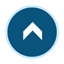](#contents)

<a id='data_collection'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:center; font-weight:regular; overflow:hidden"><strong>Step 2 • Data collection</strong></div>

The data used in this notebook is available as a Kaggle dataset on [**🚲 Divvy・Chicago Bikeshare Dataset**](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/), and consists of real operational data made available by the operators of Chicago's bike share system.

**Dataset Overview:** The “[Chicago Bikeshare Dataset](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/)” consists of anonymized monthly trip data from the Lyft Bikes and Scooters LLC operation of the City of Chicago’s Divvy bicycle sharing service.

**Data Science & Analytics Applications:** This dataset is recommended for Track A of the [Google Data Analytics Capstone Project](https://www.coursera.org/learn/google-data-analytics-capstone). It is valuable for analysts aiming to perform descriptive analysis, geographic analysis, trend visualization, and predictive modeling using real app data from bike-sharing services.

**The Data:** Each anonymized trip record includes:

- Trip start date and time
- Trip end date and time
- Trip start station, with its coordinates
- Trip end station, with its coordinates
- Rider type (`member` or `casual`)
- Rideable type (`electric_bike` or `classic_bike`・legacy: `docked_bike`, `electric_scooter`)

According to the data provider, Lyft:

> The data has been processed to exclude trips taken by staff for system servicing and inspection.  
> It also excludes any trip below 60 seconds (potentially false starts or users attempting to re-dock a bike for security).

**Data License Agreement:** https://divvybikes.com/data-license-agreement. 

**Acknowledgments:** Special thanks to Lyft Bikes and Scooters, LLC and The City of Chicago for making this data publicly available. 

**Source:** Lyft Bikes and Scooters, LLC [🔗](https://divvy-tripdata.s3.amazonaws.com/index.html)

<br>

[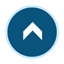](#contents)

<a id='data_prep'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:center; font-weight:regular; overflow:hidden"><strong>Step 3 • Data prep</strong></div>


<a id='loading'></a>

## ⧗ Loading the data

In [1]:
# ⧗ Loading the data

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas            as pd    # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy             as np    # linear algebra
import matplotlib.pyplot as plt   # dataviz (lower-level)
import seaborn           as sns   # dataviz (higher-level, advanced statistical plotting with automatic styling and minimal code)

import missingno         as msno  # visualize missing data
from datetime import timedelta    # datetime operations
from IPython.display import display, display_markdown  # pretty print

from pandas.api.types import CategoricalDtype  # to define month and day_of_week text as sorted categories

!pip install mermaid-python -q -q -q  # programmatic interface for generating diagrams and visualizations
from mermaid import Mermaid           # used in section 3. Data prep > Dimensional Modeling > Conceptual Data Model

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/divvy-tripdata/divvy-tripdata.csv


[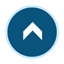](#contents)

<a id='inspecting'></a>

## ⌕ Inspecting the data

A first step when starting to explore a dataset is to 'get a feel' of it, by understanding:
* its general content
* columns, column labels, column data types

This is following performed with the use of pandas methods `df.head()`, and `df.info()`, respectively, after turning the `divvy-tripdata.csv` file into a pandas `DataFrame`:

In [2]:
# Check the first rows
df = pd.read_csv('/kaggle/input/divvy-tripdata/divvy-tripdata.csv')
display_markdown('#### Data • First rows<br>', raw=True)
df.head()

#### Data • First rows<br>

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9340B064F0AEE130,electric_bike,2023-07-23 20:06:14,2023-07-23 20:22:44,Kedzie Ave & 110th St,20204,Public Rack - Racine Ave & 109th Pl,877,41.692406,-87.700905,41.694835,-87.653041,member
1,D1460EE3CE0D8AF8,classic_bike,2023-07-23 17:05:07,2023-07-23 17:18:37,Western Ave & Walton St,KA1504000103,Milwaukee Ave & Grand Ave,13033,41.898418,-87.686596,41.891578,-87.648384,member
2,DF41BE31B895A25E,classic_bike,2023-07-23 10:14:53,2023-07-23 10:24:29,Western Ave & Walton St,KA1504000103,Damen Ave & Pierce Ave,TA1305000041,41.898418,-87.686596,41.909396,-87.677692,member
3,9624A293749EF703,electric_bike,2023-07-21 08:27:44,2023-07-21 08:32:40,Racine Ave & Randolph St,13155,Clinton St & Madison St,TA1305000032,41.884112,-87.656943,41.882752,-87.641190,member
4,2F68A6A4CDB4C99A,classic_bike,2023-07-08 15:46:42,2023-07-08 15:58:08,Clark St & Leland Ave,TA1309000014,Montrose Harbor,TA1308000012,41.967088,-87.667291,41.963982,-87.638181,member


In [3]:
# Check the type of each column, and the total number of records
display_markdown('#### Column types and overall number of records<br>', raw=True)
df.info()

#### Column types and overall number of records<br>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11900875 entries, 0 to 11900874
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 1.2+ GB


[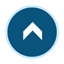](#contents)

<a id='type_casting'></a>

## 𖤘 Setting appropriate data types

Our initial inspection of the dataset's columns with `df.info()`, presented above, reveals that some of them are not originally in the ideal type for data analysis:

| Column          | Current Type   | Target Type   |
| ---             | ---            | ---           |
| `started_at`    | `object`       | `datetime`    |
| `ended_at`      | `object`       | `datetime`    |
| `rideable_type` | `object`       | `category`    |
| `member_casual` | `object`       | `category`    |

<br>

For performance and memory usage, high-cardinality fields (those with a large number of distinct values) are kept as `object` rather than being converted to `category`.  

Conversion to the target types is performed below:

In [4]:
# Type cast

# Convert to datetime
df[['started_at', 'ended_at']] = df[['started_at', 'ended_at']].apply(pd.to_datetime)

# Convert to category
df[['rideable_type', 'member_casual']] = df[['rideable_type', 'member_casual']].astype('category')

# Check final data types
display_markdown('#### Column types, after conversion<br>', raw=True)
df.info()

#### Column types, after conversion<br>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11900875 entries, 0 to 11900874
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       category      
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       category      
dtypes: category(2), datetime64[ns](2), float64(4), object(5)
memory usage: 1021.5+ MB


[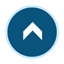](#contents)

<a id='data_quality'></a>

## **✓** Ensuring Data Quality

The **value** of **insights derived from data** relies on its underlying **quality**. For data-driven decision-making, transparency in data processing is crucial for trust and confidence in the conclusions presented.  

Multiple **frameworks** exist to ensure data quality from raw records to final insights. This project adopts a compact version of the comprehensive methodology presented by [**The Data Management Association (DAMA)**](https://www.dama.org/) in its [**Data Management Body of Knowledge (DMBoK)**](https://technicspub.com/dmbok2/). DAMA's DMBoK is recognized as the leading guide for international data management standards and practices, built on the hands-on expertise of seasoned professionals.

Specifically, **open access documents** by the [Nederland Chapter of DAMA International](https://dama-nl.org/), prepared by data quality auditing firm «&nbsp;[Van Nederpelt](https://www.linkedin.com/in/petervannederpelt/) & [Black](https://www.linkedin.com/in/andrewblackeu/)&nbsp;,» are here applied:

* **Dimensions of Data Quality (DDQ)** [🔗](https://www.dama-nl.org/wp-content/uploads/2020/09/DDQ-Dimensions-of-Data-Quality-Research-Paper-version-1.2-d.d.-3-Sept-2020.pdf)
* Code for Information Quality 2020 [🔗](https://www.dama-nl.org/wp-content/uploads/2020/02/Code-for-Information-Quality-2020-DAMA-EN_2_1.pdf)

Out of the sixty data quality dimensions presented in the DDQ document, this notebook focuses on a subset of six universal dimensions, identified by the acronym **CutCVA**:  

<p style="font-size:36px; margin-bottom:0.5em;">
    C<span style="font-size:21px;">heck    </span> 
    u<span style="font-size:21px;">p,      </span> 
    t<span style="font-size:21px;">hen     </span> 
    C<span style="font-size:21px;">onfirm: </span> 
    V<span style="font-size:21px;">alidate,</span> 
    A<span style="font-size:21px;">lways.  </span>
</p>

&nbsp;&nbsp;&nbsp;&nbsp;☐ **C** ompleteness  
&nbsp;&nbsp;&nbsp;&nbsp;☐ **u** niqueness  
&nbsp;&nbsp;&nbsp;&nbsp;☐ **t** imeliness  
&nbsp;&nbsp;&nbsp;&nbsp;☐ **C** onsistency  
&nbsp;&nbsp;&nbsp;&nbsp;☐ **V** alidity  
&nbsp;&nbsp;&nbsp;&nbsp;☐ **A** ccuracy  

The [University of Michigan **Total Data Quality** Specialization](https://online.umich.edu/series/total-data-quality/) emphasizes that the **practical objective** of Data Quality is to ensure data are **fit for purpose**: Conclusions drawn from the variables of interest reliably reflect reality. Pursuing perfect quality across every dimension is often impractical and economically unjustified. This pragmatic perspective guides the work presented here. The following sections show how the key Data Quality dimensions are assessed and ensured for the variables used in this case study.

---

**Other relevant frameworks**  

For exploring additional methodologies for data quality and management, other relevant frameworks include:
* **ISO 9001**:2015 • Quality management systems [🔗](https://www.iso.org/standard/62085.html)
* **ISO 8000**-1:2022 • Data quality [🔗](https://www.iso.org/standard/81745.html)
* **ISO 31000**:2018 • Risk management [🔗](https://www.iso.org/standard/65694.html)
* **COSO • ERM** • Committee of Sponsoring Organizations Enterprise Risk Management [🔗](https://www.coso.org/guidance-erm)
* **ITIL** • Information Technology Infrastructure Library [🔗](https://www.itlibrary.org/)
* **COBIT** • Control Objectives for Information Technologies [🔗](https://www.isaca.org/resources/cobit)
* **MIT TDQM** • Total Data Quality Management Conceptual Framework [🔗](https://web.mit.edu/tdqm/www/tdqmpub/SURVEYIEEEKDEAug95.pdf)[🔗](https://www.researchgate.net/figure/Conceptual-Framework-of-Data-Quality-Wang-and-Strong-1996_fig2_254707240) by Wang and colleagues [🔗](https://www.linkedin.com/in/richard-wang-mitcdoiq/)[🔗](https://ieeexplore.ieee.org/author/37377595500)[🔗](https://dblp.org/pid/77/3485.html)
* **U-Mich TDQ** • University of Michigan Total Data Quality Framework [🔗](https://online.umich.edu/series/total-data-quality/) by Buskirk and colleagues [🔗](https://www.linkedin.com/in/tbuskirk/)[🔗](https://www.si.umich.edu/people/jinseok-kim/)[🔗](https://surveydatascience.isr.umich.edu/faculty-member/wagner/)[🔗](https://www.linkedin.com/in/brady-west-a769a73/)

---

<figure>
  <img
    src='https://raw.githubusercontent.com/isis-santos-costa/isis-santos-costa/refs/heads/main/img/data-quality-dimensions---design-by-Claude.png'
    alt='Data Quality Dimensions: CutCVA Framework • Design by Claude' />
  <figcaption><strong>Data Quality Dimensions: CutCVA Framework</strong><br>Adapted from DAMA-DMBoK and Escola Politécnica da USP • Design by Claude</figcaption>
</figure>

Relevant measures to the questions tackled in this notebook are listed below:

1. **When** do members typically rent a bike versus when do casual users? `started_at`, `ended_at`
2. **How long** are member rides versus casual rides? `started_at`, `ended_at`
3. **Where** do members ride versus where do casual users? `start_lat`, `start_lng`, `end_lat`, `end_lng`, `start_station_id`, `end_station_id`, `start_station_name`, `end_station_name`

Focusing on efficiency and on practical data quality levels, the dataframe is following reduced to just these variables, besides the `ride_id` and the `member_casual` dimension. 

In [5]:
# Feature selection

df = df[[ 'ride_id'        \
        , 'member_casual'  \
        , 'start_station_id'  , 'end_station_id'   \
        , 'start_station_name', 'end_station_name' \
        , 'started_at', 'ended_at' \
        , 'start_lat' , 'end_lat'  \
        , 'start_lng' , 'end_lng'  ]]
display_markdown("#### Selected variables for the project<br>", raw=True)
df.head()

#### Selected variables for the project<br>

,ride_id,member_casual,start_station_id,end_station_id,start_station_name,end_station_name,started_at,ended_at,start_lat,end_lat,start_lng,end_lng
0,9340B064F0AEE130,member,20204,877,Kedzie Ave & 110th St,Public Rack - Racine Ave & 109th Pl,2023-07-23 20:06:14,2023-07-23 20:22:44,41.692406,41.694835,-87.700905,-87.653041
1,D1460EE3CE0D8AF8,member,KA1504000103,13033,Western Ave & Walton St,Milwaukee Ave & Grand Ave,2023-07-23 17:05:07,2023-07-23 17:18:37,41.898418,41.891578,-87.686596,-87.648384
2,DF41BE31B895A25E,member,KA1504000103,TA1305000041,Western Ave & Walton St,Damen Ave & Pierce Ave,2023-07-23 10:14:53,2023-07-23 10:24:29,41.898418,41.909396,-87.686596,-87.677692
3,9624A293749EF703,member,13155,TA1305000032,Racine Ave & Randolph St,Clinton St & Madison St,2023-07-21 08:27:44,2023-07-21 08:32:40,41.884112,41.882752,-87.656943,-87.641190
4,2F68A6A4CDB4C99A,member,TA1309000014,TA1308000012,Clark St & Leland Ave,Montrose Harbor,2023-07-08 15:46:42,2023-07-08 15:58:08,41.967088,41.963982,-87.667291,-87.638181


### Completeness

According to literature [🔗](https://doi.org/10.1287/mnsc.31.2.150), data completeness is defined as the inclusion of **all necessary values** within a dataset:
> All values for a certain variable are recorded.

For an overall quick check of data completeness, the `msno.matrix` function from the `missingno` library enables a specific data quality visualization, fit for the purpose, as seen on the [Cyclistic Data Analysis](https://www.kaggle.com/code/sh184roman/cyclistic-data-analysis/) by [Roman Shrestha](https://www.kaggle.com/sh184roman), and applied below.

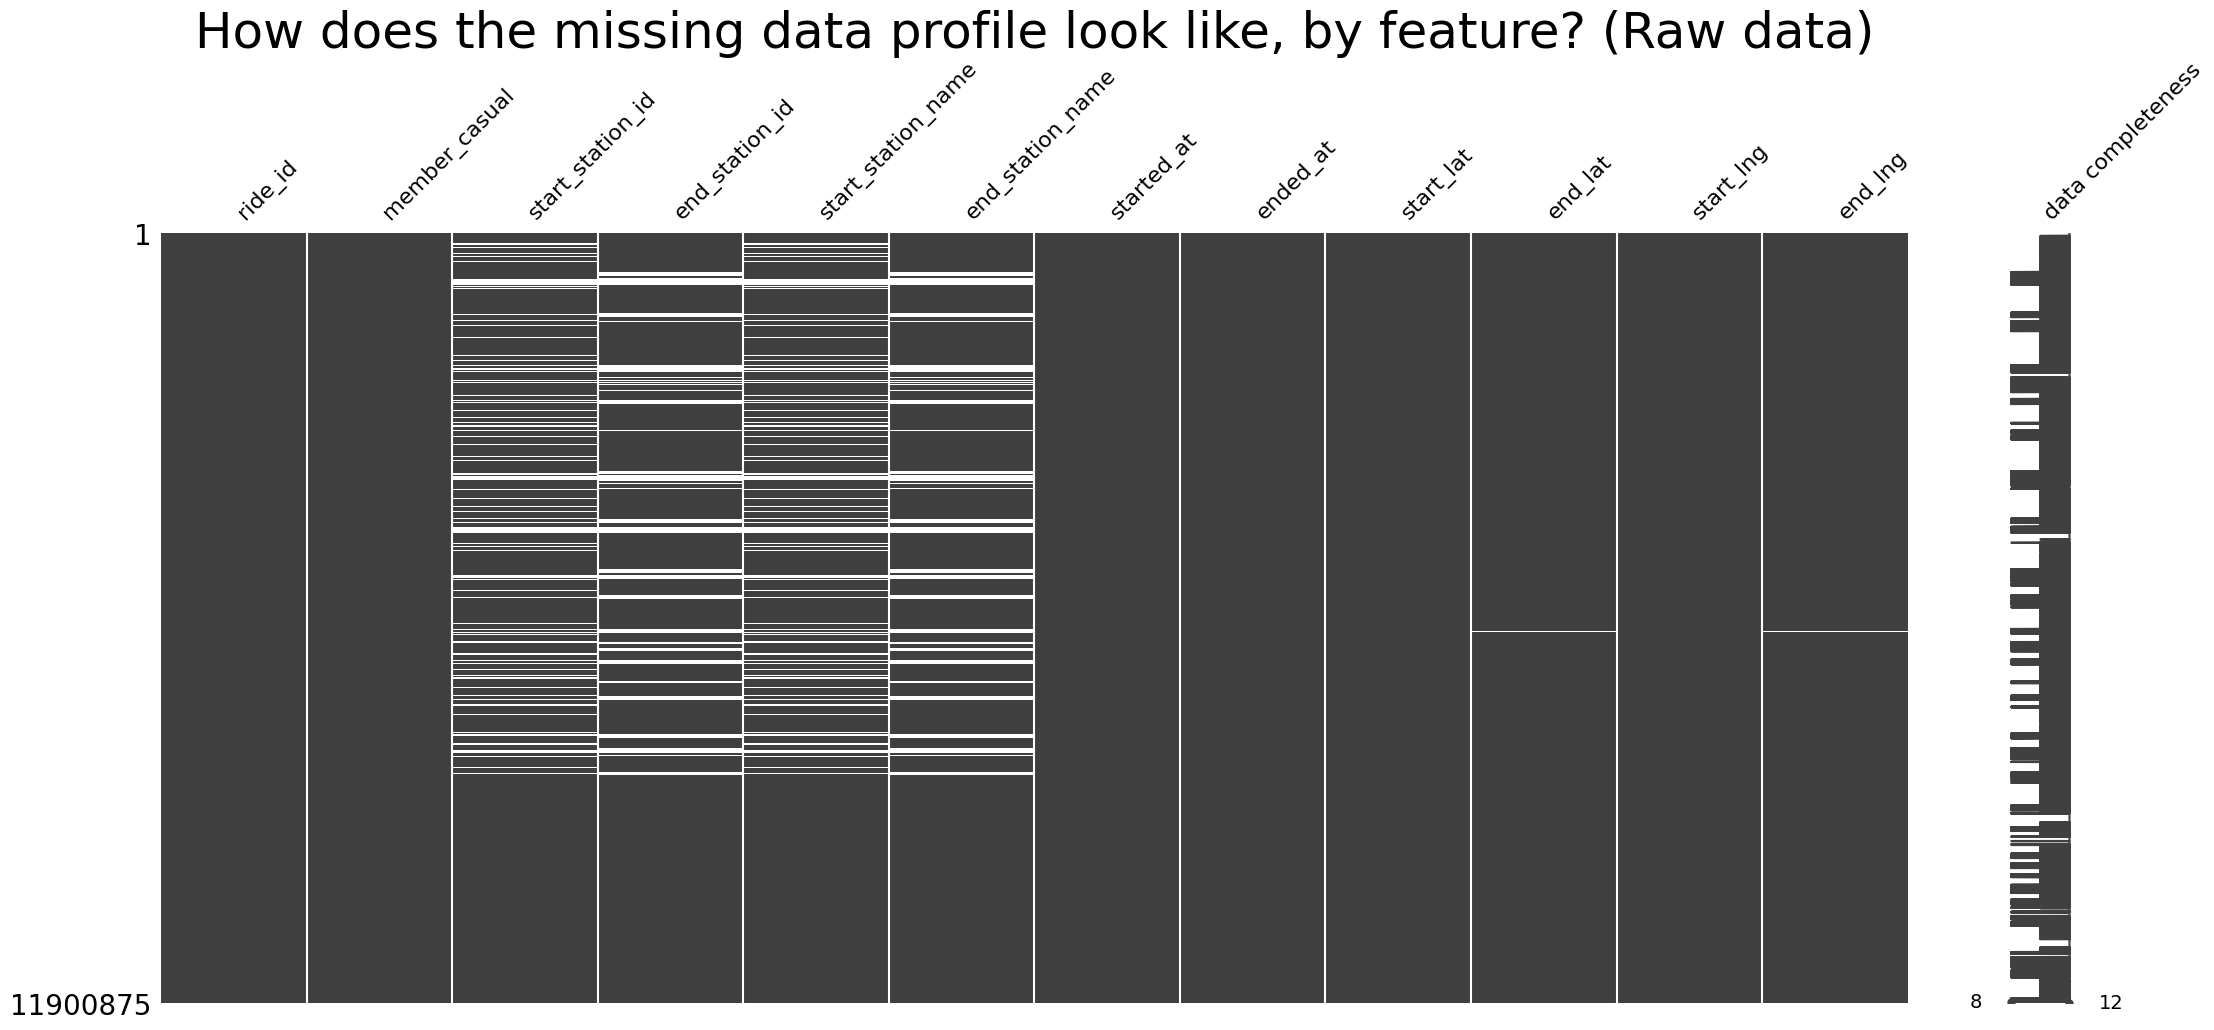

In [6]:
# Data Quality • Completeness → How does the missing data profile look like, by feature?

msno.matrix(df, labels=True)
plt.title('How does the missing data profile look like, by feature? (Raw data)', fontsize=36)
plt.show()

The chart above identifies `(start/end)_station_id` and `(start/end)_station_name` as the variables with the highest missingness. Because they extend information already provided by the corresponding latitude and longitude coordinates, records are treated as sufficiently complete for this project. Later, during the **uniqueness** assessment, a **canonical entity mapping** is applied to assign a single canonical station name to each coordinate pair.

Completeness is following evaluated considering the analytical objective of the study. Since the goal goes through constrasting the behavior of **casual riders** to that of **members**, a key requirement is that missing data do not materially distort **the relative representation of the two groups** across the variables used in the analysis.

To detect potential distortions, the next code cell plots a time series of the **member-to-casual record ratio** for each relevant variable across the dataset’s full history. The chart provides a quick visual check for unusual oscillations that could indicate completeness issues affecting the comparison.

<p style="font-size:36px">Are the missing data biased toward a particular customer segment?</p>

#### Summary statistics: Daily ride counts by metric and user segment &nbsp;|&nbsp; Raw data<br>

started_at_cnt        ended_at_cnt        start_lat_cnt         \
member_casual         casual member       casual member        casual member   
count                    761    761          761    761           761    761   
mean                    5666   9971         5666   9971          5666   9971   
std                     4413   4500         4413   4500          4413   4500   
min                       61    505           61    505            61    505   
25%                     1717   6323         1717   6323          1717   6323   
50%                     4671  10406         4671  10406          4671  10406   
75%                     8762  13956         8762  13956          8762  13956   
max                    19044  19414        19044  19414         19044  19414   

              end_lat_cnt        start_lng_cnt        end_lng_cnt         
member_casual      casual member        casual member      casual member  
count                 761    761           761    761         761    761  
mean                 5651   9968          5666   9971        5651   9968  
std                  4399   4499          4413   4500        4399   4499  
min                    54    497            61    505          54    497  
25%                  1713   6320          1717   6323        1713   6320  
50%                  4659  10403          4671  10406        4659  10403  
75%                  8739  13953          8762  13956        8739  13953  
max                 19007  19412         19044  19414       19007  19412

#### Summary statistics: Daily member-to-casual ratios per metric (wide format) &nbsp;|&nbsp; Raw data<br>

,started_at_cnt_member_to_casual_ratio,ended_at_cnt_member_to_casual_ratio,start_lat_cnt_member_to_casual_ratio,end_lat_cnt_member_to_casual_ratio,start_lng_cnt_member_to_casual_ratio,end_lng_cnt_member_to_casual_ratio
count,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000
mean,2.639281,2.639281,2.639281,2.646793,2.639281,2.646793
std,1.459896,1.459896,1.459896,1.471920,1.459896,1.471920
min,0.673440,0.673440,0.673440,0.674646,0.673440,0.674646
25%,1.644268,1.644268,1.644268,1.647835,1.644268,1.647835
50%,2.179215,2.179215,2.179215,2.193170,2.179215,2.193170
75%,3.447844,3.447844,3.447844,3.471989,3.447844,3.471989
max,10.983607,10.983607,10.983607,12.092593,10.983607,12.092593


#### Overall summary statistics of combined member-to-casual ratio &nbsp;|&nbsp; Raw data<br>

,count,mean,std,min,25%,50%,75%,max
ratio,4566.0,2.641785,1.463118,0.67344,1.644785,2.183489,3.465953,12.092593


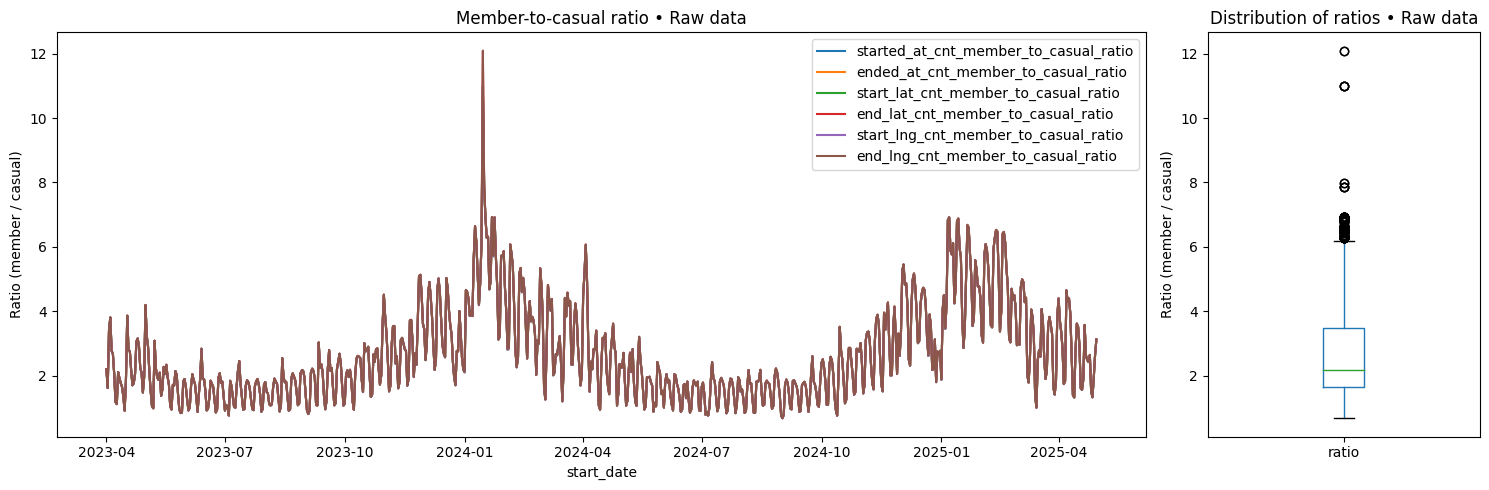

In [7]:
# Data Quality • Completeness → Are the missing data biased toward a particular customer segment?

display_markdown('<p style="font-size:36px">Are the missing data biased toward a particular customer segment?</p>', raw=True)

# ------------------------------------------------------------------------------------------------------------------------------
# 1. Get count ratio for each of the selected variables, for visual checking
# ------------------------------------------------------------------------------------------------------------------------------
# Create column for daily aggregation
df['start_date'] = df['started_at'].dt.date

# Count records for each day and `member_casual` ride type
record_count = df.groupby([df['start_date'], df['member_casual']]).agg(
    started_at_cnt = ('started_at', 'count'),
      ended_at_cnt = (  'ended_at', 'count'),
     start_lat_cnt = ( 'start_lat', 'count'),
       end_lat_cnt = (   'end_lat', 'count'),
     start_lng_cnt = ( 'start_lng', 'count'),
       end_lng_cnt = (   'end_lng', 'count')
)

# Unstack the 'member_casual' index level
unstacked_count_filled = record_count.unstack(level='member_casual').fillna(0) # fillna ensures perfect pairing
display_markdown('#### Summary statistics: Daily ride counts by metric and user segment &nbsp;|&nbsp; Raw data<br>', raw=True)
display(unstacked_count_filled.describe().astype(int))

# Create DataFrame to store calculated ratios, same index as unstacked counts (the dates)
ratio = pd.DataFrame(index=unstacked_count_filled.index)

# Calculate ratios
for count_type in unstacked_count_filled.columns.levels[0]:
    member_series = unstacked_count_filled[(count_type, 'member')]
    casual_series = unstacked_count_filled[(count_type, 'casual')]
    ratio_series  = member_series / casual_series
    ratio[f'{count_type}_member_to_casual_ratio'] = ratio_series
print('\n')
display_markdown('#### Summary statistics: Daily member-to-casual ratios per metric (wide format) &nbsp;|&nbsp; Raw data<br>', raw=True)
display(ratio.describe())

# ------------------------------------------------------------------------------------------------------------------------------
# 2. Get a sorted list of ratios, to capture discrepancies
# ------------------------------------------------------------------------------------------------------------------------------
# Unpivot ratios
ratio_long = pd.melt(
    ratio.reset_index(),
    id_vars=['start_date'],  # The column(s) to keep as identifiers
                             # value_vars is optional here, as all other columns are value columns
    var_name='count_type',   # New column name for the melted column headers
    value_name='ratio'       # New column name for the values
).set_index('start_date')

# Clean up 'count_type', and sort
ratio_long['count_type'] = ratio_long['count_type'].str.replace('_member_to_casual_ratio', '')
ratio_long = ratio_long.sort_values(by='ratio', ascending=False)
print('\n')
display_markdown('#### Overall summary statistics of combined member-to-casual ratio &nbsp;|&nbsp; Raw data<br>', raw=True)
display(ratio_long.describe().T)

# ------------------------------------------------------------------------------------------------------------------------------
# 3. Display
# ------------------------------------------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [12, 3]})

ratio.plot(ax=axes[0])
axes[0].set_title ('Member-to-casual ratio • Raw data')
axes[0].set_ylabel('Ratio (member / casual)')

ratio_long.boxplot(column='ratio', ax=axes[1], grid=False)
axes[1].set_title ('Distribution of ratios • Raw data')
axes[1].set_ylabel('Ratio (member / casual)')

plt.tight_layout()
plt.show()

The tables and charts above support us in answering the following questions:
* What does the **member-to-casual ratio** look like for **each of the selected variables** over the whole analyzed period?
* Do the observed **ratios** remain **stable over time**?
* Are any **outstanding ratios** explainable by the **operational process** rather than by data capture issues?

<br>

From '_**Summary statistics: Daily ride counts by metric and user segment**_' above, we observe that there were **rides every day**, for both user segments, throughout the considered period (as min `started_at_cnt` = 61, not zero). The same summary also suggests **data loss** affecting **trip endpoint geolocation**. This is inferred from the lower record counts for endpoint geolocation variables (casual: 5,651; member: 9,968), compared with the remaining variables (casual: 5,666; member: 9,971).

The same pattern becomes even clearer in _**Summary statistics: Daily member-to-casual ratios per metric**_. **Endpoint geolocation** variables consistently exhibit higher member-to-casual ratios, indicating that **missing records disproportionately affect casual riders** rather than both groups equally. This introduces **systematic bias** due to missingness, **potentially affecting the conclusions** of this case study.

From the charts, on the time series plot, on the left, **we observe a distinct peak**, indicating a substantial departure from the typical member-to-casual ratio. On the right, the overall distribution is presented as a boxplot, showing **outliers**, with some exceeding five times the median ratio.

Taken together, the tables and charts suggest that the observed ratio shifts cannot be explained solely by operational variability. Because trip completion (`ended_at_cnt`) remains consistent with the remaining variables, the evidence instead points to a **decoupling** between the processes that record **trip completion** and **trip endpoint geolocation**, resulting in **missing endpoint coordinates**.

<br>

In the next code cell, let's further inspect the issue, looking at some qualitative questions:
* What do these **outlier days** have **in common**?
* Do they occur **systematically**?

Finally, let's wrap-up the **data completeness** check by assessing: 
* How many **days** contain at least one **outlier**?
* What **percentage of all analyzed days** do these **outliers** represent?
* What **percentage of all ratio observations** are classified as outliers?

<p style="font-size:36px">What can be the drivers for the missing data?</p>

**20 days (2.628121%) presented at least one outlier**: 2024-01-09 • 2024-01-14 • 2024-01-15 • 2024-01-16 • 2024-01-17 • 2024-01-18 • 2024-01-19 • 2024-01-22 • 2024-01-24 • 2025-01-06 • 2025-01-07 • 2025-01-13 • 2025-01-14 • 2025-01-21 • 2025-01-22 • 2025-02-11 • 2025-02-12 • 2025-02-13 • 2025-02-17 • 2025-02-18



**Outliers were observed in only 3 year-months** (out of total 25): 2024-01 • 2025-01 • 2025-02

**Outlier ratio observations**: 120 outlier count / 4,566 overall count = 2.628121%

Notice that every anomalous day affected all monitored metrics (120 days = 6 metrics × 20 days). This strongly suggests an operational event affecting all monitored metrics on those days. Observe, though, that, combined with the specific values from _**Summary statistics: Daily member-to-casual ratios per metric (wide format)  |  Raw data**_, the remark about a potential biased loss between the segments (casuals vs members) is reinforced, and seen in the chart below:

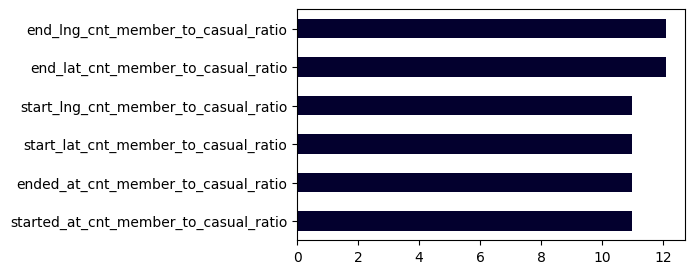

In [8]:
# Data Quality • Completeness → What can be the drivers for the missing data?

display_markdown('<p style="font-size:36px">What can be the drivers for the missing data?</p>', raw=True)

# ------------------------------------------------------------------------------------------------------------------------------
# 1. Calculate upper and lower fences
# ------------------------------------------------------------------------------------------------------------------------------
# Calculate Q1, Q3, and IQR for each 'count_type'
quartiles = ratio_long.groupby('count_type')['ratio'].quantile([0.25, 0.75]).unstack()
quartiles.columns = ['Q1', 'Q3'] # Rename columns for clarity

# Calculate IQR
quartiles['IQR'] = quartiles['Q3'] - quartiles['Q1']

# Calculate upper and lower fences
quartiles['lower_fence'] = quartiles['Q1'] - (1.5 * quartiles['IQR'])
quartiles['upper_fence'] = quartiles['Q3'] + (1.5 * quartiles['IQR'])

# print('Distribution for each variable')
# print(quartiles)

# ------------------------------------------------------------------------------------------------------------------------------
# 2. Identify the outlier days
# ------------------------------------------------------------------------------------------------------------------------------
# Join fence values to the daily ratios
ratio_with_fences = pd.merge(
    ratio_long.reset_index(),
    quartiles[['lower_fence', 'upper_fence']],
    on='count_type',
    how='left'
)

# Identify rows where 'ratio' is outside the fences
# We use a boolean mask
outlier_mask = (ratio_with_fences['ratio'] < ratio_with_fences['lower_fence']) | \
               (ratio_with_fences['ratio'] > ratio_with_fences['upper_fence'])

# Filter the DataFrame to get only the outlier observations
outliers_detected = ratio_with_fences[outlier_mask].sort_values(by='start_date')

# print('\nOutlier observations detected')
# print(outliers_detected)

# Get a list of unique days with at least one outlier
outlier_days = sorted(outliers_detected['start_date'].unique())
total_unique_days = df['start_date'].nunique()
proportion_of_days_w_outliers = len(outlier_days) / total_unique_days
outlier_days_txt = f'**{len(outlier_days)} days ({proportion_of_days_w_outliers:%}) presented at least one outlier**: ' + ' • '.join(map(str, outlier_days))
display_markdown(outlier_days_txt, raw=True)

# Get a list of unique year-months with at least one outlier
unique_ym_count = pd.to_datetime(df['start_date']).dt.to_period('M').nunique()
outlier_ym = sorted((outliers_detected['start_date'].astype(str).str.slice(0, 7)).unique())
outlier_ym_text = f'\n\n**Outliers were observed in only {len(outlier_ym)} year-months** (out of total {unique_ym_count}): ' + ' • '.join(map(str, outlier_ym))
display_markdown(outlier_ym_text, raw=True)

selected_var_record_cnt  = len(ratio_long)
selected_var_outlier_cnt = len(ratio_long[ratio_long.index.isin(outlier_days)])
proportion_of_records_w_outliers = selected_var_outlier_cnt / selected_var_record_cnt
obs_txt = f'**Outlier ratio observations**: {selected_var_outlier_cnt:,} outlier count / {selected_var_record_cnt:,} overall count = {proportion_of_records_w_outliers:%}'
display_markdown(obs_txt, raw=True)

print()

analysis_txt  = 'Notice that every anomalous day affected all monitored metrics (120 days = 6 metrics × 20 days). '
analysis_txt += 'This strongly suggests an operational event affecting all monitored metrics on those days. '
analysis_txt += 'Observe, though, that, combined with the specific values from _**Summary statistics: Daily member-to-casual ratios per metric (wide format)  |  Raw data**_, '
analysis_txt += 'the remark about a potential biased loss between the segments (casuals vs members) is reinforced, and seen in the chart below:'
display_markdown(analysis_txt, raw=True)

ratio.max().sort_values().plot.barh(figsize=(5, 3), color='#03002e');

From the results seen above, we conclude that:
* The distribution of daily record count is **similar across the selected variables**.
* The ratio distribution characteristics are identical for most variables, with a **difference** observed only for the **endpoint geolocation**.
* The **differing ratios** do not appear to be solely justifiable by the operational process itself, as `ended_at_cnt` (count of  date and time when a trip ended) aligns with other variables. This discrepancy therefore indicates a **data loss** for endpoint geolocation only.
* We notice that the outlier days occurred in **January** and **February** (a pattern further explored below).
* The **anomalies exhibit temporal clustering** (based on two years of observations), with **casual riders' percentage notably decreasing in Jan and Feb**.

Finally, regarding our approach to these days:
* A total of 20 days was identified as presenting an abnormally high member-to-casual ratio.
* Out of an overall total of 761 days being considered, these represent about **2.6% of the days**.
* In terms of **individual ratio observations** identified as outliers, this represents 120 observations out of a total of 4,566 analyzed, also about **2.6%**.

#### Dealing with the outliers  
Considering our **goal** of getting a **grasp on the major trends** in Cyclistic bike **usage behavior of members versus casual users**, for quantitative purposes **let's drop the outlier days**, as well as days for which there is a **lack of records of any of the selected variables** (except for station names, for the reason mentioned before). In addition, let's **take notice** of how the **member-to-casual ratio** varies **along the year**. Regarding the root causes for geolocation data loss in January and February in Chicago, a qualitative discussion is presented below.

---

From [Google Search AI Overview](http://google.com/) on **«&nbsp;what's special in chicago in jan feb&nbsp;»**:  
> Chicago in January and February offers a unique blend of **winter activities** and **indoor attractions**. _Choose Chicago_ suggests that winter brings opportunities for ice skating at Chicago Park District, exploring winter gardens, and enjoying live theater or comedy. The city also boasts festivals like _Tomorrow Never Knows_ and _The Morton Arboretum's_ holiday light displays.
> > Key aspects of Chicago in January and February:  
> > **Cold Weather**: **January is the coldest month**, with average temperatures around 30°F (-1°C), and February also sees very chilly weather.
> **Indoor Activities**: Many attractions like museums, art galleries, and theaters offer a welcome escape from the cold.
> **Outdoor Fun**: Ice skating at Millennium Park and Maggie Daley Park, and even rooftop curling, are popular winter activities.
> > **Festivals and Events**: The city hosts various events and festivals, including indie music and comedy at Tomorrow Never Knows and the Winter Flower Show.
> > **Holiday Lights**: The Morton Arboretum, the Garfield Park Conservatory offers a Winter Flower Show.
> > **Sports**: You can cheer for the Chicago Bears, Bulls, or Blackhawks during the winter months.
> > 
> In summary, Chicago's winter offers a mix of fun in the **snow** and **indoor attractions**, making it a worthwhile destination even in the colder months.

 ---

By [Gemini 2.5 Flash](https://gemini.google.com/), on factors potentially causing **data loss** for the **endpoint geolocation**:

**«&nbsp;How cold weather could cause data loss&nbsp;»**  
* **Sensor/GPS Malfunction**: Extreme cold can affect the performance of GPS units, battery life, or other sensors on the bikes or docking stations, leading to patchy or failed location data recordings.  
* **User Behavior in Cold**: Casual riders might be less inclined to properly dock or end a ride if they are rushing to get indoors, or if the docking mechanism itself is frozen/malfunctioning, leading to incomplete transaction data. Or perhaps the bikes are left in places where GPS signal is weaker (e.g., covered areas to avoid snow).  
* **Operational Changes**: It's also possible (though less likely for "loss") that operations change slightly in winter (e.g., staff less frequently checking stations, different maintenance procedures) that could indirectly impact data collection fidelity.

**«&nbsp;What could cause data loss biased towards the end-of-journey geolocation?&nbsp;»**  
* **Battery Drain & Cold Impact**: GPS modules and data transmitters consume power. As a ride progresses, the bike's battery drains. Cold weather significantly reduces battery efficiency and capacity. By the end of a longer ride in freezing temperatures, the battery might be critically low, causing the GPS unit or the data transmission module to fail or operate unreliably, leading to a missed final location ping.  
* **Docking Station Environment & Signal Issues**: Docking stations are often located in specific urban environments. If these stations are in areas with poor GPS signal reception (e.g., under large structures, within dense urban canyons, or even inside covered/sheltered areas to avoid snow), the bike might lose its precise location signal just as it's being returned. The system might rely on the bike itself to send the final GPS coordinates upon successful docking. If the GPS is weak at that precise moment, the timestamp of the ride ending might be recorded by the station's internal clock or network, but the coordinates are lost.  
* **User Behavior (Especially in Cold/Rush)**: _**Expedited Docking**_: In cold weather, users, especially casual riders, might be eager to get indoors quickly. They might hastily dock the bike without ensuring it's fully locked and registered, potentially interrupting a final data transmission. _**App Interaction**_: If ending a ride also involves an app interaction that requires a stable network or GPS signal, a user rushing the process in cold conditions might fail to complete that step robustly, leading to incomplete end-of-trip data.  
* **System Design & Redundancy**: It's possible the system has different redundancies for start vs. end locations. A start location is critical for unlocking a bike, so there might be more robust mechanisms (e.g., cell tower triangulation, Wi-Fi triangulation, multiple GPS pings) to ensure that first location is always recorded accurately. End locations might have less stringent requirements or rely on a single, more fallible method.

---

The observed **increase in missing endpoint geolocation for casual riders**, together with the hypothetical causes for it (including behavior that could increase operational costs, for example, by 'rescuing lost bicycles' in more frequent dead spots by casuals than for members), is **consistent with the Finance team's finding** that show **members** as not only bringing more revenue, but as being also **more _profitable_**.

<p style="font-size:36px">Data Quality • Completeness → Cleanup</p>

#### Missing values • Raw data<br>

,Missing values count,Missing values percentage
ride_id,0,0.00
member_casual,0,0.00
start_station_id,2036853,17.12
end_station_id,2123700,17.84
start_station_name,2036853,17.12
end_station_name,2123700,17.84
started_at,0,0.00
ended_at,0,0.00
start_lat,0,0.00
end_lat,14404,0.12


**Raw data record count**: 11,900,875 records

**Record count after data completeness clean-up for member-to-casual record count ratio outlier days**: 11,835,073 records

...

started_at_cnt        ended_at_cnt        start_lat_cnt         \
member_casual         casual member       casual member        casual member   
count                    741    741          741    741           741    741   
mean                    5792  10160         5792  10160          5792  10160   
std                     4372   4398         4372   4398          4372   4398   
min                      273   1152          273   1152           273   1152   
25%                     1864   6595         1864   6595          1864   6595   
50%                     4865  10655         4865  10655          4865  10655   
75%                     8815  14009         8815  14009          8815  14009   
max                    19007  19412        19007  19412         19007  19412   

              start_lng_cnt        end_lat_cnt        end_lng_cnt         
member_casual        casual member      casual member      casual member  
count                   741    741         741    741         741    741  
mean                   5792  10160        5792  10160        5792  10160  
std                    4372   4398        4372   4398        4372   4398  
min                     273   1152         273   1152         273   1152  
25%                    1864   6595        1864   6595        1864   6595  
50%                    4865  10655        4865  10655        4865  10655  
75%                    8815  14009        8815  14009        8815  14009  
max                   19007  19412       19007  19412       19007  19412

#### Summary statistics: Daily member-to-casual ratios per metric (wide format) &nbsp;|&nbsp; Cleaned-up data<br>

,started_at_cnt_member_to_casual_ratio,ended_at_cnt_member_to_casual_ratio,start_lat_cnt_member_to_casual_ratio,start_lng_cnt_member_to_casual_ratio,end_lat_cnt_member_to_casual_ratio,end_lng_cnt_member_to_casual_ratio
count,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000
mean,2.530566,2.530566,2.530566,2.530566,2.530566,2.530566
std,1.291867,1.291867,1.291867,1.291867,1.291867,1.291867
min,0.674646,0.674646,0.674646,0.674646,0.674646,0.674646
25%,1.629966,1.629966,1.629966,1.629966,1.629966,1.629966
50%,2.160026,2.160026,2.160026,2.160026,2.160026,2.160026
75%,3.300207,3.300207,3.300207,3.300207,3.300207,3.300207
max,6.169553,6.169553,6.169553,6.169553,6.169553,6.169553


#### Overall summary statistics of combined member-to-casual ratios &nbsp;|&nbsp; Cleaned-up data<br>

,count,mean,std,min,25%,50%,75%,max
ratio,4446.0,2.530566,1.29114,0.674646,1.629966,2.160026,3.300207,6.169553


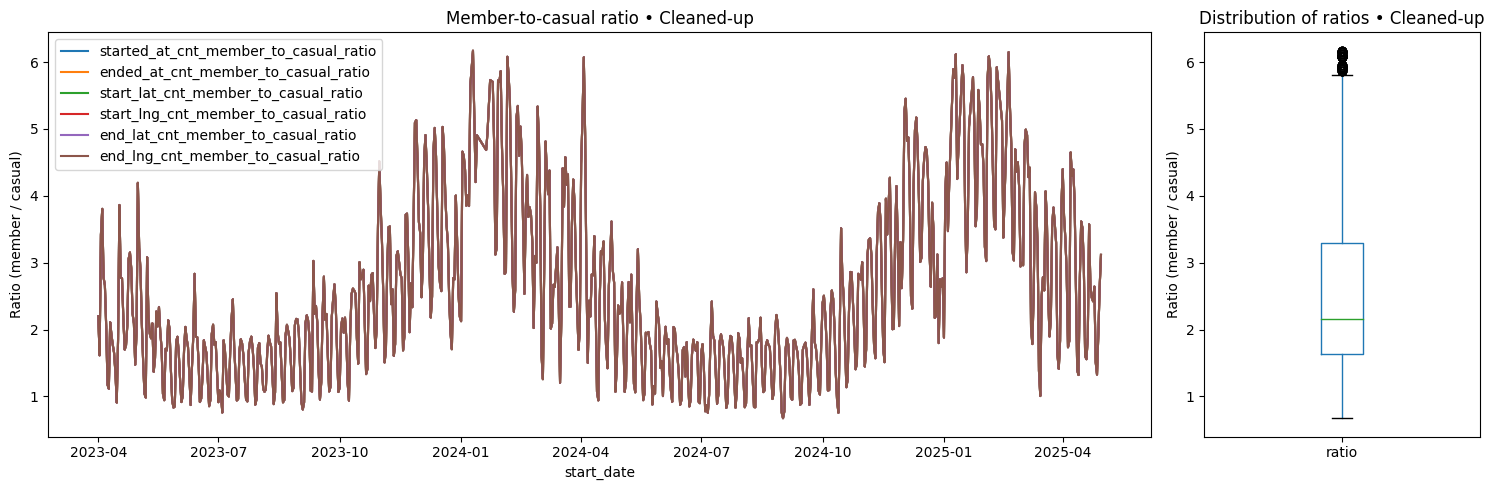

In [9]:
# Data Quality • Completeness → Cleanup

display_markdown('<p style="font-size:36px">Data Quality • Completeness → Cleanup</p>', raw=True)

# Calculate NA count and percentage
na_count      = df.isna().sum().astype(int)
na_percentage = (100 * df.isna().sum() / len(df)).round(2)

# Create the summary DataFrame
na_summary_df = pd.DataFrame({
    'Missing values count'     : na_count,
    'Missing values percentage': na_percentage
})

# Filter to show only columns with missing values
# na_summary_df = na_summary_df[na_summary_df['Missing values count'] > 0]

# Display the result
display_markdown('#### Missing values • Raw data<br>', raw=True)
display(na_summary_df)

# Keep track of the original record count
record_count_0_original = len(df)
print('')
display_markdown(f'**Raw data record count**: {record_count_0_original:,} records', raw=True)

# Drop outlier days
df = df[df['start_date'].isin(outlier_days)==False]

# Keep track of the updated record count
record_count_1_completeness_oulier_days = len(df)
display_markdown(f'**Record count after data completeness clean-up for member-to-casual record count ratio outlier days**: {record_count_1_completeness_oulier_days:,} records', raw=True)

# Drop records with missing values for the selected variables
selected_columns = ['started_at', 
                    'ended_at',
                    'start_lat',
                    'start_lng',
                    'end_lat',
                    'end_lng']
df = df.dropna(subset=selected_columns)

# Keep track of the updated record count
record_count_2_completeness_selected_var_na = len(df)
display_markdown(f'**Record count after data completeness clean-up for missing values of selected variables**: {record_count_2_completeness_selected_var_na:,} records', raw=True)

# TODO: Define na_summary_df, ratios, ratios_long and quartiles as f(df) to enable easy reassessment at this point

print('')
# Calculate NA count and percentage
na_count      = df.isna().sum().astype(int)
na_percentage = (100 * df.isna().sum() / len(df)).round(2)

# Create the summary DataFrame
na_summary_df = pd.DataFrame({
    'Missing values count'     : na_count,
    'Missing values percentage': na_percentage
})

# Filter to show only columns with missing values
# na_summary_df = na_summary_df[na_summary_df['Missing values count'] > 0]

# Display the result
display_markdown('#### Missing values • Cleaned-up data<br>', raw=True)
display(na_summary_df)


# ------------------------------------------------------------------------------------------------------------------------------
# 1. Get count ratio for each of the selected variables, for visual checking
# ------------------------------------------------------------------------------------------------------------------------------
# Create column for daily aggregation
df['start_date'] = df['started_at'].dt.date

# Count records for each day and `member_casual` ride type
record_counts = df.groupby([df['start_date'], df['member_casual']]).agg(
    started_at_cnt = ('started_at', 'count'),
      ended_at_cnt = (  'ended_at', 'count'),
     start_lat_cnt = ( 'start_lat', 'count'),
     start_lng_cnt = ( 'start_lng', 'count'),
       end_lat_cnt = (   'end_lat', 'count'),
       end_lng_cnt = (   'end_lng', 'count')
)

# Unstack the 'member_casual' index level
unstacked_counts_filled = record_counts.unstack(level='member_casual').fillna(0) # fillna ensures perfect pairs
display_markdown('#### Summary statistics: Daily ride counts by metric and user segment &nbsp;|&nbsp; Cleaned-up data<br>', raw=True)
display(unstacked_counts_filled.describe().astype(int))

# Create DataFrame to store calculated ratios, same index as unstacked counts (the dates)
ratios = pd.DataFrame(index=unstacked_counts_filled.index)

# Calculate ratios
for count_type in unstacked_counts_filled.columns.levels[0]:
    member_series = unstacked_counts_filled[(count_type, 'member')]
    casual_series = unstacked_counts_filled[(count_type, 'casual')]
    ratio_series  = member_series / casual_series
    ratios[f'{count_type}_member_to_casual_ratio'] = ratio_series
print('\n')
display_markdown('#### Summary statistics: Daily member-to-casual ratios per metric (wide format) &nbsp;|&nbsp; Cleaned-up data<br>', raw=True)
display(ratios.describe())

# ------------------------------------------------------------------------------------------------------------------------------
# 2. Get a sorted list of ratios, to capture discrepancies
# ------------------------------------------------------------------------------------------------------------------------------
# Unpivot ratios
ratios_long = pd.melt(
    ratios.reset_index(),
    id_vars=['start_date'],  # The column(s) to keep as identifiers
                             # value_vars is optional here, as all other columns are value columns
    var_name='count_type',   # New column name for the melted column headers
    value_name='ratio'       # New column name for the values
).set_index('start_date')

# Clean up 'count_type', and sort
ratios_long['count_type'] = ratios_long['count_type'].str.replace('_member_to_casual_ratio', '')
ratios_long = ratios_long.sort_values(by='ratio', ascending=False)
print('\n')
display_markdown('#### Overall summary statistics of combined member-to-casual ratios &nbsp;|&nbsp; Cleaned-up data<br>', raw=True)
display(ratios_long.describe().T)

# ------------------------------------------------------------------------------------------------------------------------------
# 3. Display graphically
# ------------------------------------------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [12, 3]})

ratios.plot(ax=axes[0])
axes[0].set_title ('Member-to-casual ratio • Cleaned-up')
axes[0].set_ylabel('Ratio (member / casual)')

ratios_long.boxplot(column='ratio', ax=axes[1], grid=False)
axes[1].set_title ('Distribution of ratios • Cleaned-up')
axes[1].set_ylabel('Ratio (member / casual)')

plt.tight_layout()
plt.show()

Final check on completeness:
* Missing values are now only observed for metrics not focused on the study (start/end `_station_name`, `_station_id`).
* '_**Summary statistics: Daily ride counts by metric and user segment**_' now shows the **exact same count** for each metric and user segment.
* '_**Summary statistics: Daily member-to-casual ratios per metric (wide format)**_' now shows the **exact same ratio** for each metric and user.
* Our time series on **member-to-casual ratio** now oscillates gracefully, in compatibility with a natural profile expected for seasonality.
* The **outliers** shown on the boxplot now lie **quite close** to the upper fence limit.

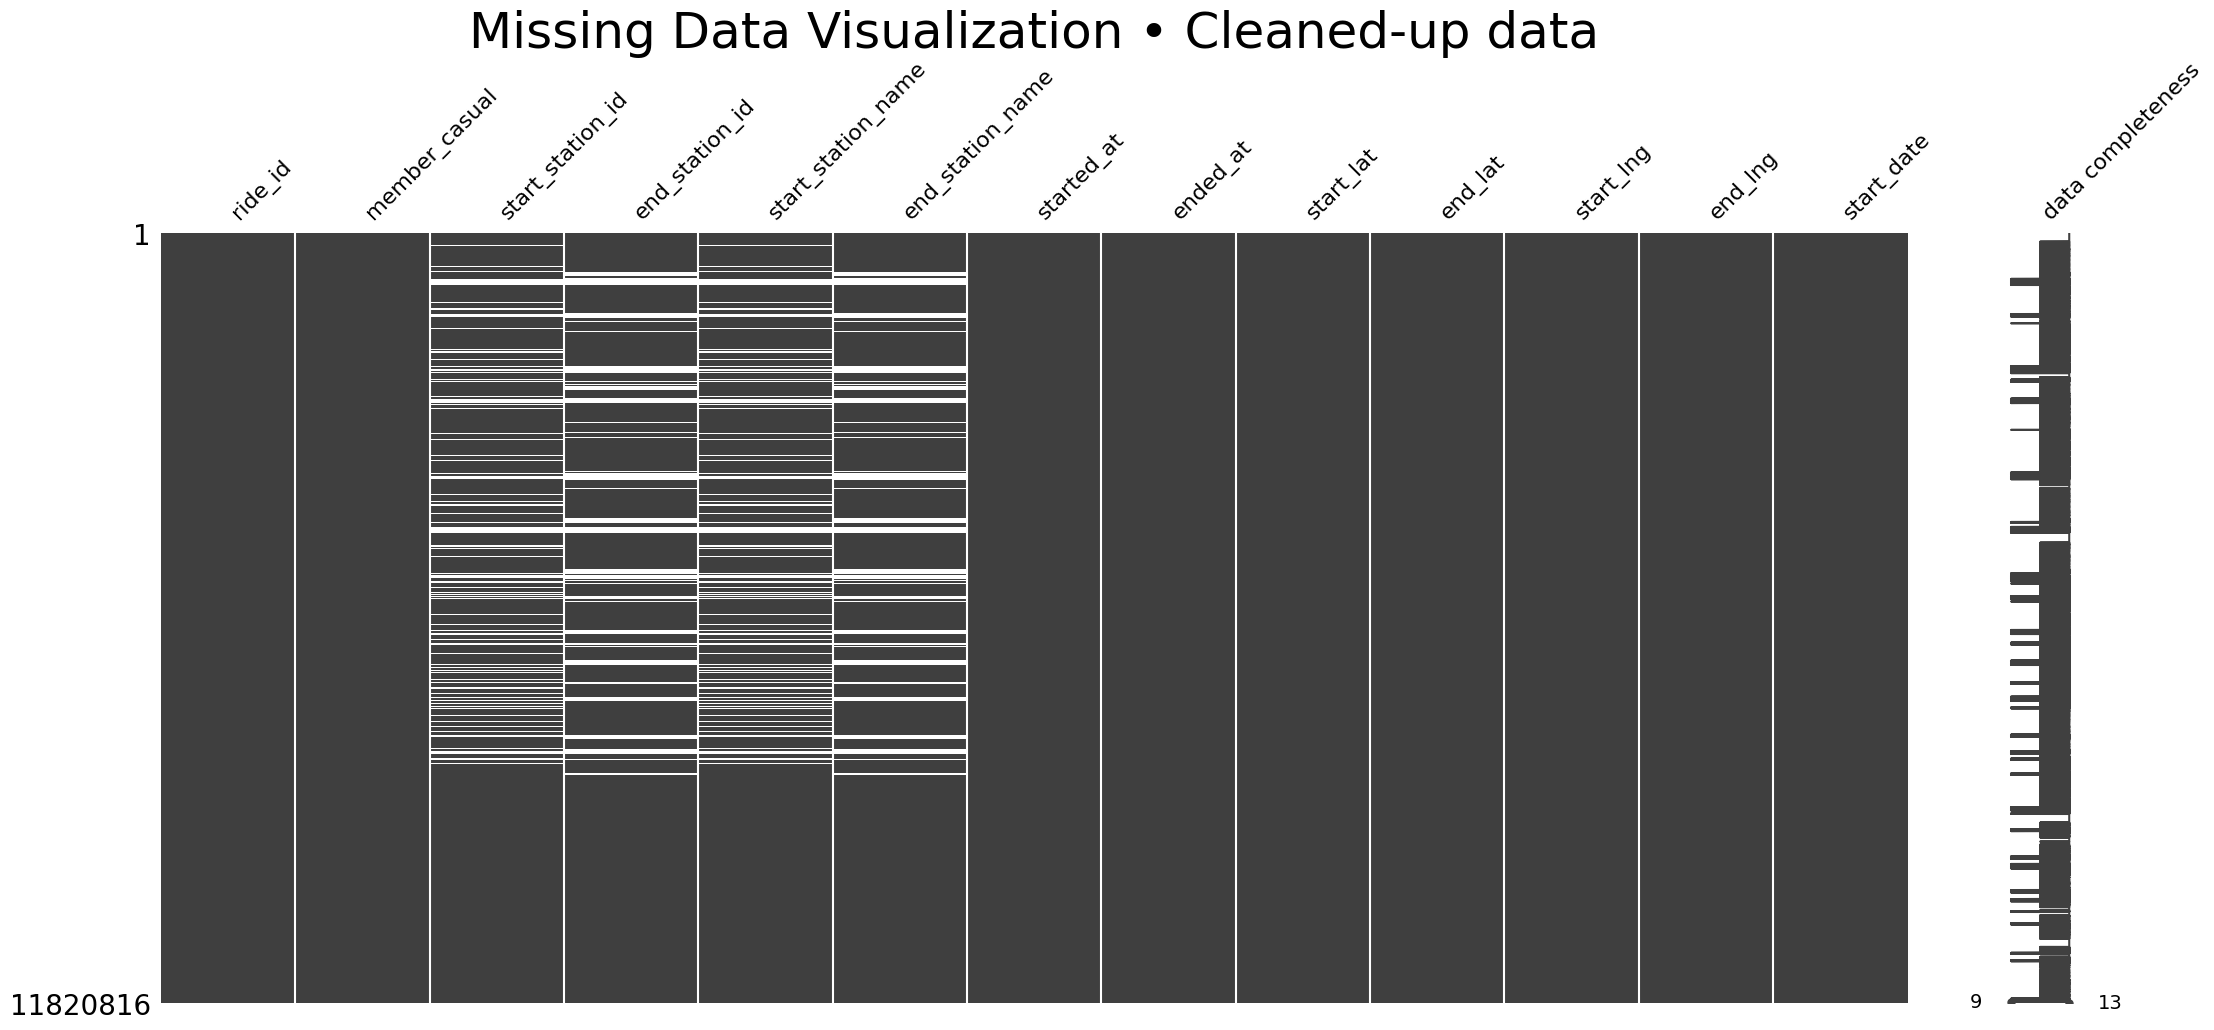

In [10]:
# Data Quality • Completeness → Cleaned-up data

msno.matrix(df, labels=True)
plt.title('Missing Data Visualization • Cleaned-up data', fontsize=36)
plt.show()

#### **✓** **C**ompleteness: checked.

<br>

[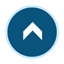](#contents)

### Uniqueness

In the context of Data Quality, **Uniqueness** is defined as follows [🔗](https://www.dama-nl.org/wp-content/uploads/2020/09/DDQ-Dimensions-of-Data-Quality-Research-Paper-version-1.2-d.d.-3-Sept-2020.pdf):

> The degree to which records occur only once in a data file.

Let's take a look again at the variables concerned in this study.

In [11]:
# Data Quality • Uniqueness → Data fields in the project

display_markdown('#### Data fields in the project', raw=True)
list(df.columns)

#### Data fields in the project

['ride_id',
 'member_casual',
 'start_station_id',
 'end_station_id',
 'start_station_name',
 'end_station_name',
 'started_at',
 'ended_at',
 'start_lat',
 'end_lat',
 'start_lng',
 'end_lng',
 'start_date']

From the list, we observe that most columns are expected to contain possible coincident or repeated values (e.g., multiple rides starting at the same time or location). The sole exception is the `ride_id`, which, as per the [dataset](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/) documentation, should uniquely identify **one record per ride**.  

The dataset further mentions a preparation step. The corresponding notebook shows that the original data, made monthly available, stores rides spanning two months in both of the files (e.g. a ride started on May 31, ended on June 1st gets reported in both the May and the June files). Therefore, a [deduplication step](https://www.kaggle.com/code/isissantoscosta/combine-csv-files?scriptVersionId=240721478&cellId=10) was performed during that initial preparation to ensure each ride is represented exactly once.

In the next cell, we'll verify for **`ride_id` uniqueness** by displaying:
* Total records
* Unique `ride_id`
* Total duplicated rows

In [12]:
# Data Quality • Uniqueness → Simple uniqueness (`ride_id`)

display_markdown('#### Ride ID Uniqueness', raw=True)

display_markdown(f"##### Total records: {len(df):,}"                      , raw=True)
display_markdown(f"##### Unique `ride_id`: {df['ride_id'].nunique():,}"   , raw=True)
display_markdown(f"##### Total duplicated rows: {df.duplicated().sum():,}", raw=True)

#### Ride ID Uniqueness

##### Total records: 11,820,816

##### Unique `ride_id`: 11,820,816

##### Total duplicated rows: 0

#### Station Uniqueness

Beyond uniqueness of individual fields, certain **combinations of fields** may also be expected to be unique, by what is called **composite uniqueness**. This is the case for Cyclistic's stations. Each `(start/end_)station_id` is expected to correspond to exactly one `(start/end_)station_name` (except for legitimate name updates) and one `(start/end)_(lat/lng)` pair. On the same reasoning, each set of `(start/end_)station_name` and `(start/end)_(lat/lng)` must map to a single `(start/end_)station_id`.  

In an ideal state, each station identifier maintains a **one-to-one** relationship with its attributes: every `(start/end_)station_id` maps to exactly one name and one coordinate pair, and vice versa. Data quality issues arise when these relationships become one-to-many, and must be addressed. In dimensional modeling and data governance, managing this evolution over time is known as handling **Slowly Changing Dimensions (SCD)**. Considering that the focus of this study is the customer experience, and that stations serve the purpose of revealing customer interests, the Kimball SCD technique **Type 1 (Overwrite)** [🔗](https://www.kimballgroup.com/2008/08/slowly-changing-dimensions/) will be adopted. This approach simplifies the dimension by updating and standardizing earlier `(start/end_)station_name` values into a single, current canonical form, treating multiple name versions over time as a data quality issue, rather than meaningful business signal.      

Considering that station names may change over long periods of time, the following **steps** will be performed in **transforming data** to ensure station uniqueness:

* **Canonicalize station names**:  
  In case multiple `(start/end_)station_name`s are found for a single `(start/end)_station_id`, all records will be replaced by the _mode_ calculated on the latest 20% of the `(start/end_)station_name` time series (assuming recent data reflects current naming conventions). In cases of tied mode values, the alphabetically first value is selected for consistency.
  
* **Canonicalize station IDs**:  
  If, conversely, multiple `(start/end)_station_id`s are associated with a single `(start/end_)station_name`, they will be replaced by the _mode_ of the most recent 20% of `(start/end)_station_id` data.

* **Single out coordinates**:  
  To ensure a single association between each station and its coordinates, the high precision and potential noise in GPS recordings make a consistent value for the mode of coordinates unlikely. The _median_ value of `(start/end)_(lat/lng)`, robust against outliers, will be defined as the canonical coordinate for the station, replacing noisy raw data.

* **Exception (free-floating locations)**:  
  In the edge case of `(start/end)_station_(NULL id & NULL name)` being recorded for a specific `(start/end)_(lat/lng)`, we may assume that there may exist exceptional events in which the bicycle is not redeemed from /returned at a proper station. To appropriately cover these cases, instead of a `dim_station`, a `dim_location` will be used ahead in the [🗲 Dimensional Modeling](#dimensional_modeling) section, as it comprises both proper stations and free-floating locations.

The final outcome of these transformations will be a lookup canonical table for stations, plus the full list of free-floating locations. Combined, they establish a robust foundation for dimensional modeling, ensuring reliable joins and accurate location analytics.  

---

**Slowly Changing Dimensions (SCD) • Techniques** [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/books/data-warehouse-dw-toolkit/)

* Type 0 • Retain original
* **Type 1 • Overwrite**
* Type 2 • Add new row
* Type 3 • Add new attribute
* Type 4 • Add mini-dimension
* Type 5 • Add mini-dimension and Type 1 outrigger
* Type 6 • Add Type 1 attributes to Type 2 dimension
* Type 7 • Dual Type 1 and Type 2 dimensions

**More on Slowly Changing Dimensions (SCD):**
* Full discussion, Types 0 to 7: Kimball & Ross, _The Data Warehouse Toolkit_, 3rd ed, pp. 53-56. [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/books/data-warehouse-dw-toolkit/)
* Type 1 • Overwrite: [Kimball Group • Slowly Changing Dimensions (SCD)](https://www.kimballgroup.com/2008/08/slowly-changing-dimensions/)

---

<a id='modular_design'></a>

**Modular Design**

The station lookup table—mapping station variations to their canonical `station_id`, `station_name`, and coordinates—will be built using a modular pipeline design. Specifically, the framework by [dbt • Data Build Tool](https://www.getdbt.com/) will be adopted, oriented toward an Analytics Development Life Cycle (ADLC) mindset. Modular data pipelines improve **maintainability**, **scalability**, and **reuse** by decomposing transformations into independent components. dbt operationalizes this philosophy through **layered models** connected as a **Directed Acyclic Graph (DAG)** [🔗](https://medium.com/@axel.westeinde/monolith-modular-mesh-modern-architecture-for-modern-data-platforms-2c0802ee0881).  

This approach offers several benefits [🔗](https://www.prefect.io/blog/building-a-modular-data-architecture):  
* Separation of concerns
* Loose coupling between components
* High cohesion within components
* Standardized interaction interfaces

The typical layers of a dbt pipeline [🔗](https://www.getdbt.com/blog/modular-data-modeling-techniques) are the following, with their role presented just after:  
`Source (Raw)` → `Base (optional layer)` → `Staging` → `Intermediate (optional layer)` → `Data Marts: Fact, Dimension, Aggregate, and Report Tables`

* **Source (Raw)**: Houses the original data, _as-is_, for auditing, review, and eventual change of preprocessing rules.
* **Base (optional)**: Used to combine or split raw data for its initial processing.
* **Staging**: For basic transformations like data type casting, column renaming, and filtering of extraneous records.
* **Intermediate (optional)**: For overly complex or nested mart models, built to increase readability, and reusability.  
* **Data Marts**: Final user interfacing layer, usually connected to Business Intelligence (BI) or Machine Learning (ML) tools.

A good practice prescribed in the framework is to have design a 1-to-1 relationship between source and staging tables [🔗](https://www.getdbt.com/blog/modular-data-modeling-techniques). In a full-fledged environment, our source would be `raw_rides`. As, at this point, we aim at focusing solely on **locations**, comprised of **stations** and **free-floating locations**, let's build from `raw_stations` and `raw_free_floating_locations`.

The resulting pipeline handles the mentioned three distinct data quality scenarios, and is given by the following Directed Acyclic Graph (DAG) [🔗](https://popsql.com/learn-dbt/dbt-dag)[🔗](https://hevodata.com/data-transformation/dbt-dag/)[🔗](https://www.getdbt.com/blog/dag-use-cases-and-best-practices):

* `raw_stations` → `base_stations_non_null_name_non_null_id` → `stg_stations` → `int_stations_canonical` → `dim_location`
* `raw_stations` → `base_stations_non_null_name_null_id` → `stg_stations` → `int_stations_canonical` → `dim_location`
* `raw_free_floating_locations` → `base_stations_null_name_null_id` → `stg_free_floating_locations` → `dim_location`

<figure>
    <img src='https://raw.githubusercontent.com/isis-santos-costa/divvy/refs/heads/main/img/canonicalization-of-stations.png', alt='Data Quality • Uniqueness: Canonicalization of Stations  |  DAG • Directed Acyclic Graph, Prepared with Excalidraw'></img>
    <figcaption>
        <strong>Data Quality • Uniqueness: Canonicalization of Stations &nbsp;|&nbsp; DAG • Directed Acyclic Graph</strong><br>
            Prepared with Excalidraw
    </figcaption>
</figure>

<br>

Since this section focuses specifically on **Data Quality • Uniqueness**, the following codes cells are dedicated to creating the stations and free-floating locations staging tables. These transformations are applied at the staging layer, and serve as treated data downstreams, avoiding repeated and potentially conflicting computations in downstream marts. This DAG will be referenced again in the [🗲 Dimensional Modeling](#dimensional_modeling) section, when creating table `dim_location`, building on the staged data.  

---

**More on Modular Design:**
* dbt Labs • Data modeling techniques for more modularity [🔗](https://www.getdbt.com/blog/modular-data-modeling-techniques)
* Monolith, Modular, Mesh: modern architecture for modern data platforms [🔗](https://medium.com/@axel.westeinde/monolith-modular-mesh-modern-architecture-for-modern-data-platforms-2c0802ee0881)
* How to Move Beyond a Monolithic Data Lake to a Distributed Data Mesh [🔗](https://martinfowler.com/articles/data-monolith-to-mesh.html)
* How to Make Your Data Models Modular [🔗](https://medium.com/data-science/how-to-make-your-data-models-modular-71b21cdf5208)
* Building a Modular Data Architecture [🔗](https://www.prefect.io/blog/building-a-modular-data-architecture)

### 🚧 Work in Progress

#### **✓** **u**niqueness: checked.

<br>

[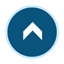](#contents)

### Timeliness

The definition for **timeliness** is given on the previously mentioned _DDQ • Dimensions for Data Quality_ paper [🔗](https://www.dama-nl.org/wp-content/uploads/2020/09/DDQ-Dimensions-of-Data-Quality-Research-Paper-version-1.2-d.d.-3-Sept-2020.pdf):

> The degree to which the period between the time of creation of the real value and the time that the dataset is available is appropriate.

#### The Business Problem

To this quality dimension, the Marketing department wants to consider:
- Is the data fresh enough for timely user outreach?

As seen on [Step 2: <strong>Data collection</strong>](#data_collection), data used in this project is made available monthly. This is longer than usual, due to the particular case of the reference data being public, and the same would be expected to be available to internal teams at an earlier point.

Let's, anyway, assume this as the earliest time when data gets effectively made available to the Marketing department. According to Klavyio, 1-2 weeks post delivery (a bike trip, in our case) is the ideal time to reach out to customers for loyalty programs [🔗](https://www.klaviyo.com/blog/post-purchase-emails#:~:text=6.,coming%20back%20for%20future%20purchases.). 

#### Strategic Approach

Considering that data is not timely available for direct outreach of users based on their on data, we want to use historical data to define clear standards for customer behavior so that once these are met by future customers, we're in a position to immediately reach out to them with our best offer for their needs. 

A concept that comes handy here is that of an **ICP, Ideal Customer Profile**. Most frequently used at B2B (business-to-business) companies [🔗](https://www.salesforce.com/blog/ideal-customer-profile/), the definition of an ideal profile for customers is also applicable to B2C (business-to-customer) businesses, especially in the case of building loyalty [🔗](https://pixis.ai/blog/ideal-customer-profile-vs-buyer-persona/)[🔗](https://frictionlesshq.com/ideal-customer-profiles-vs-buyer-personas-whats-the-difference/).

The definition of an ICP may get increasingly refined, combining product usage data with data from external sources. In order to have a kick-start, let's define here a Cyclistic member ICP based on trip duration and usage time.

#### Conclusion
As the ideal window for reaching out to customers is 1-2 weeks, and data is available monthly, it is thus **not timely enough for direct outreach**. A robust—and also more systemic—approach is to pre-define an Ideal Customer Profile, ICP. For the purpose of defining an ICP, data is available on **almost 12 million rides** spanning **two years of operations**; that considered, **data for defining an ICP is sufficient and timely**.

#### **✓** **T**imeliness: checked.

<br>

[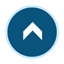](#contents)

### Consistency

> Data consistency refers to the state of data in which all copies or instances are the same across all systems and databases. [🔗](https://www.ibm.com/think/topics/data-consistency-vs-data-integrity#:~:text=for%20more%20information.-,What%20is%20data%20consistency?,database%20systems%2C%20applications%20and%20platforms.)

Given the context of this analysis, consisting of data gathered from a single point, that compiles from a single source, the data is cohesive, and consistent.

#### **✓** **C**onsistency: checked.

<br>

[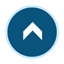](#contents)

### Validity

According to the [Nederland Chapter of DAMA International](https://dama-nl.org/), in their white paper named **Dimensions of Data Quality (DDQ)** [🔗](https://www.dama-nl.org/wp-content/uploads/2020/09/DDQ-Dimensions-of-Data-Quality-Research-Paper-version-1.2-d.d.-3-Sept-2020.pdf):

> Validity refers to whether data values are consistent with a defined domain of values.

Looking again at the questions targeted by this notebook:

1. **When** do casual riders typically rent bikes, compared to members? `started_at`, `ended_at`
2. **How long** does a typical ride take for casual riders versus members? `started_at`, `ended_at`
3. **Where** do casual riders go versus members? `start_lat`, `start_lng`, `end_lat`, `end_lng`, `start_station_id`, `end_station_id`, `start_station_name`, `end_station_name` ( future version )

For this version, the only variables of interest are `started_at`, `ended_at`, and their difference, that gives the trip duration.
The next code cell adds the column `duration` to the dataframe.
Then, a description of the range and key metrics on the distribution of each of these variables is presented.

### 🚧 Work in Progress

#### **✓** **V**alidity: checked.

<br>

[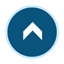](#contents)

### Accuracy

According to data intelligence tool Collibra [🔗](https://www.collibra.com/blog/the-6-dimensions-of-data-quality#:~:text=Measuring%20data%20accuracy%20requires%20verification,promote%20this%20data%20quality%20dimension.):

> Data accuracy is the level to which data represents the real-world scenario and confirms with a verifiable source.  
> Measuring data accuracy requires verification with authentic references such as official birth records.

Strategies to ensure data accuracy, as per the above mentioned document by Collibra, involve successful data governance, to ensure data preservation through its entire journey.

As mentioned on [Step 2 • Data collection](#data_collection), the data used in this notebook is from Kaggle dataset [**🚲 Chicago Divvy Bikeshare Dataset**](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/), and consists of operational data made available by the operators of Chicago's bike share system, Divvy.

Given the fact that the data is made available by its providers, the feasible action for this analysis, relating to data accuracy, limits to the fact that the source is reliable, and the applied transformation steps are available to track data to its source. Accuracy is thus confirmed.

#### **✓** **A**ccuracy: checked.

<br>

[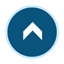](#contents)

### 🚧 Work in Progress

<a id='describing'></a>

## 🛈 Describing the data

Once all columns have been converted into the ideal data type for analysis, we can proceed with a more **detailed inspection** of the data.

In the following cells, `df.describe()` is applied to present *descriptive statistics* on central tendency, spread, and distribution profile for the numerical columns.

For categorical data, list the specific **categories** observed for each field is displayed using `df.['column'].unique()`.

### 🚧 Work in Progress

[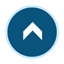](#contents)

<a id='feature_engineering'></a>

## ⛯ Feature Engineering

Following the clean-up and data quality check, some transformations are useful to prepare data for analysis. This process uses domain knowledge to turn raw data into meaningful features—the input variables for our analysis. 

Revisiting the user behavior questions this notebook addresses:

1. **When** do casual riders typically rent bikes, compared to members? `started_at`, `ended_at`
2. **How long** does a typical ride take for casual riders versus members? `started_at`, `ended_at`
3. **Where** do casual riders go versus members? `start_lat`, `start_lng`, `end_lat`, `end_lng`, `start_station_id`, `end_station_id`, `start_station_name`, `end_station_name` ( future version )

The first question, _when_, unpacks into multiple perspectives:
* _When_ in the year
* _When_ in the month
* _When_ in the week
* _When_ in the day

Extraction of the relevant components of date and time information simplifies the analysis:
* `start_month_of_year`
* `start_week_of_month`
* `start_day_of_week`
* `start_hour_of_day`

To enable standardized comparisons across months with different number of days, it is more meaningful to compare daily rides rather than total monthly rides. For this calculation, the column `start_last_of_month` is added. This, along with other date components, enables the creation of the above date dimensions, planned for reporting:
* `start_year`
* `start_last_of_month`
* `start_day_of_month`

For Question 2, the `duration` of rides was already calculated during the data quality check. For the daily aggregation, a `duration_range` will be useful.  

For Question 3, since geographic analysis is not included in the current version of this notebook, no features are created at this time.

These features have been identified based on the analytical questions above. In the next section, [🗲 Dimensional Modeling](#dimensional_modeling), 
they will be implemented within a dimensional data structure (organizing features 
into fact and dimension tables), for productivity of analysis.

<br>

[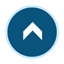](#contents)

<a id='dimensional_modeling'></a>

## 🗲 Dimensional Modeling

To ensure analytical accuracy and query performance, the data is modeled following the Star Schema [🔗](https://www.databricks.com/glossary/star-schema) of the Kimball dimensional framework [🔗](https://www.kimballgroup.com/wp-content/uploads/2013/08/2013.09-Kimball-Dimensional-Modeling-Techniques11.pdf), which organizes data into fact tables (containing measures) and dimension tables (containing descriptive attributes).  

The Kimball framework defines a Four-Step Dimensional Design Process [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/four-4-step-design-process/):

1. Select the business process.
2. Declare the grain.
3. Identify the dimensions (attributes).
4. Identify the facts (measures).


For the bike ride business process, this analysis uses **two analytical grains**:
* Atomic grain: **Single ride** (`fct_rides`)
* Aggregated grain: **Daily rides** (`agg_daily_rides`)

The table below presents an inventory of all measures and attributes planned for analysis, identifying which ones are already available in the cleaned dataset and which ones need to be engineered.  

### Feature inventory

**Legend**
* **aux**: auxiliary field, used as an intermediate in building a final field for analysis
* **DD**: Degenerate Dimension [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/degenerate-dimension/)[🔗](https://www.kimballgroup.com/2003/06/design-tip-46-another-look-at-degenerate-dimensions/)
* **`dim`**: Dimension Table [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/dimension-table-structure/)
* **`fct`**: Fact Table [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/fact-table-structure/)
* **FK**: Foreign Key [🔗](https://vertabelo.com/blog/what-is-foreign-key/)
* **PK**: Primary Key [🔗](https://vertabelo.com/blog/what-is-primary-key/)

<div style="float: left;">  
    
| Table         | Field type      | Column                        | Description                                          | Already created?<br>(in `df`) | Applies to<br>`agg_daily_rides`? |
| :------------ | :-------------- | :---------------------------- | :--------------------------------------------------- | :---------------------------: | :------------------------------: |
| `fct_rides`   | PK, DD          | `ride_id` (PK, DD)            | Unique ride identifier                               | Y                             | N                                |
| `fct_rides`   | DD              | `member_casual` (DD)          | Customer type (member/casual)                        | Y                             | Y                                |
| `fct_rides`   | FK              | `start_station_id` (FK)       | Start station identifier                             | Y                             | Y                                |
| `fct_rides`   | FK              | `end_station_id` (FK)         | End station identifier                               | Y                             | Y                                |
| `fct_rides`   | FK              | `start_date_key` (FK)         | Start date surrogate key (YYYYMMDD format)           | N                             | Y                                |
| `fct_rides`   | DD              | `start_hour_of_day` (DD)      | Start hour of the day (0 to 23)                      | N                             | Y                                |
| `fct_rides`   | DD              | `started_at` (DD)             | Start datetime (YYYY-MM-DD HH:MM:SS format)          | Y                             | N                                |
| `fct_rides`   | DD              | `ended_at` (DD)               | End datetime (YYYY-MM-DD HH:MM:SS format)            | Y                             | N                                |
| `fct_rides`   | Measure         | `duration`                    | Duration (`timedelta64` format)                      | Y                             | Y (as Attribute, range)          |
| `fct_rides`   | Measure         | `ride_count`                  | Ride count (= 1 for `fct_rides`)                     | N                             | Y                                |
| `dim_date`    | PK              | `(start_)date_key` (PK)       | Date surrogate key (YYYYMMDD format)                 | N                             | Y                                |
| `dim_date`    | Attribute       | `(start_)date`                | Date (YYYY-MM-DD format)                             | N                             | Y                                |
| `dim_date`    | Attribute       | `(start_)month_of_year`       | Month of the year (MMM format)                       | N                             | Y                                |
| `dim_date`    | Attribute       | `(start_)week_of_month`       | Week of month (1, 2, 3, 4, 5)                        | N                             | Y                                |
| `dim_date`    | Attribute       | `(start_)day_of_week`         | Day of week (DDD format)                             | N                             | Y                                |
| `dim_date`    | Attribute (aux) | `(start_)year`                | Year (YYYY format)                                   | N                             | Y                                |
| `dim_date`    | Attribute (aux) | `(start_)last_of_month`       | Last of month (28 to 31)                             | N                             | Y                                |
| `dim_date`    | Attribute (aux) | `(start_)day_of_month`        | Day of month (1 to 31)                               | N                             | Y                                |
| `dim_station` | PK              | `(start/end_)station_id` (PK) | Unique station identifier                            | Y                             | Y                                |
| `dim_station` | Attribute       | `(start/end_)station_name`    | Station name                                         | Y                             | Y                                |
| `dim_station` | Attribute       | `(start/end_)lat`             | Latitude (DD (Decimal Degree) format, -90 to +90)    | Y                             | Y                                |
| `dim_station` | Attribute       | `(start/end_)lng`             | Longitude (DD (Decimal Degree) format, -180 to +180) | Y                             | Y                                |

</div>

<div style="clear: both;"></div>

### Design choices

Some attributes, rather than being sent to a `dim` table, are kept in the `fct` table, as Degenerate Dimensions, DD: `member_casual`, `start_hour_of_day`, `started_at`, `ended_at`. The case for `member_casual` and `start_hour_of_day` relates to the first quote from Kimball Group, below. Both of them have low cardinality and comprise of a single attribute of a dimension. Thus, creating a surrogate key [🔗](https://www.kimballgroup.com/1998/05/surrogate-keys/)[🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/dimension-surrogate-key/) for each of them, and building their corresponding `dim` table would result in absolute _zero_ simplification of the fact table, and an overall increased complexity of the data model. Regarding the choice for `started_at` and `ended_at`, it relates to the second quote, also by the Kimball Group. The exact date and time, recorded up to the second of each ride, has extremely high cardinality, close to that of the `fct` table itself. Hence, rather than substancially simplifying the querying process, as expected for dimensional modeling, it would new `dim` tables with too large row count. The recommended design, in this case, is to keep these attributes as Degenerate Dimensions in the `fct` table.

> **Centipede fact tables** (...) result when designers embed numerous foreign keys to individual low-cardinality dimension [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/centipede-fact-table/)  
> A dimension table growing proportionately with the fact table (...) [usually stems from a lurking] **degenerate dimension** [🔗]()

### Role-Playing Dimensions: `dim_station`

In the Kimball framework, a [role-playing dimension](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/role-playing-dimension/) is a single dimension table that is used to build multiple views, representing different roles or meanings they have in the `fct` table. This allows for a more robust data warehousing as, for the final user, each column has a clear and unique identification in business intelligence tools (e.g.: `start_station_name` instead of solely `station_name`). As `dim_station` has stations serving the purpose of either a starting or an ending point of each ride journey, specific views applicable are `vw_dim_station_start`, and `vw_dim_station_end`.

### Building the model


### 🚧 Work in Progress

[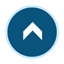](#contents)

<a id='analysis'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:center; font-weight:regular; overflow:hidden"><strong>Step 4 • Analysis</strong></div>


<a id='icp'></a>

## ⦿ Identify the Ideal Customer Profile (ICP)

### 🚧 Work in Progress

<a id='high_icp'></a>

## ◇ Find high-ICP casual users

### 🚧 Work in Progress

[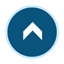](#contents)

<a id='action'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:center; font-weight:regular; overflow:hidden"><strong>Step 5 • Action</strong></div>

### 🚧 Work in Progress

<br>

[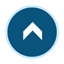](#contents)

<a id='references'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:left; font-weight:regular; overflow:hidden"><strong>References</strong></div>

**Case & Data**
* Google Data Analytics Professional Certificate • Capstone Project [🔗](https://www.coursera.org/learn/google-data-analytics-capstone/)
* 🚲 Chicago Divvy Bikeshare Dataset [🔗](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/)

**Techniques from other Kaggle users**
* Visualizing missing data: [Cyclistic Data Analysis](https://www.kaggle.com/code/sh184roman/cyclistic-data-analysis/), by [Roman Shrestha](https://www.kaggle.com/sh184roman)
* Too long, too short rides: [Cyclistic Case Study](https://www.kaggle.com/code/lukemorgan9/cyclistic-case-study/notebook), by [LukeMorgan9](https://www.kaggle.com/lukemorgan9/)

**User upgrade**
* How can you persuade customers to upgrade to a premium version of your product? [🔗](https://www.linkedin.com/advice/3/how-can-you-persuade-customers-upgrade-premium-oqeie#:~:text=You%20can%20use%20data%20analytics%2C%20surveys%2C%20interviews%2C,to%20tailor%20your%20messaging%20and%20positioning%20accordingly.)  
* How to improve user activation in 2025 [🔗](https://productfruits.com/blog/how-to-improve-user-activation/)

**Dimensional Modeling**
* Kimball & Ross, The Data Warehouse Toolkit, 3rd ed. [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/books/data-warehouse-dw-toolkit/)
* Kimball Dimensional Modeling Techniques [🔗](https://www.kimballgroup.com/wp-content/uploads/2013/08/2013.09-Kimball-Dimensional-Modeling-Techniques11.pdf)
* Databricks • Understanding Star Schema [🔗](https://www.databricks.com/glossary/star-schema)
* Kimball Group • Dimensional Modeling Techniques [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/)
* Kimball Group • Four-Step Dimensional Design Process [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/four-4-step-design-process/)
* Kimball Group • Dimension Table Structure [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/dimension-table-structure/)
* Kimball Group • Fact Table Structure [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/fact-table-structure/)
* Kimball Group • Centipede Fact Table [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/centipede-fact-table/)
* Kimball Group • Role-Playing Dimensions [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/role-playing-dimension/)
* Vertabelo • Foreign Key (FK) [🔗](https://vertabelo.com/blog/what-is-foreign-key/)
* Vertabelo • Primary Key (PK) [🔗](https://vertabelo.com/blog/what-is-primary-key/)
* Kimball Group • Surrogate Keys [🔗](https://www.kimballgroup.com/1998/05/surrogate-keys/)
* Kimball Group • Dimension Surrogate Key [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/dimension-surrogate-key/) 
* Kimball Group • Degenerate Dimensions [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/degenerate-dimension/)
* Kimball Group • Design Tip #46: Another Look At Degenerate Dimensions [🔗](https://www.kimballgroup.com/2003/06/design-tip-46-another-look-at-degenerate-dimensions/)
* Kimball Group • SCD, Slowly Changing Dimensions (Type 1 • Overwrite) [🔗](https://www.kimballgroup.com/2008/08/slowly-changing-dimensions/)
* SCD, Slowly Changing Dimensions (all techniques, Types 0 to 7) • Kimball & Ross, _The Data Warehouse Toolkit_, 3rd ed, pp. 53-56. [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/books/data-warehouse-dw-toolkit/)

**Data quality**
* Data Management Body of Knowledge (DMBoK) [🔗](https://technicspub.com/dmbok2/)
* Dimensions of Data Quality (DDQ) [🔗](https://www.dama-nl.org/wp-content/uploads/2020/09/DDQ-Dimensions-of-Data-Quality-Research-Paper-version-1.2-d.d.-3-Sept-2020.pdf)
* Code for Information Quality 2020 [🔗](https://www.dama-nl.org/wp-content/uploads/2020/02/Code-for-Information-Quality-2020-DAMA-EN_2_1.pdf)
* ISO 9001:2015 • Quality management systems[🔗](https://www.iso.org/standard/62085.html)
* ISO 80001:2022 • Data quality[🔗](https://www.iso.org/standard/81745.html)
* ISO 31000:2018 • Risk management[🔗](https://www.iso.org/standard/65694.html)
* COSO • ERM • Committee of Sponsoring Organizations Enterprise Risk Management[🔗](https://www.coso.org/guidance-erm)
* ITIL • Information Technology Infrastructure Library[🔗](https://www.itlibrary.org/)
* COBIT • Control Objectives for Information Technologies[🔗](https://www.isaca.org/resources/cobit)
* MIT TDQM • Total Data Quality Management Conceptual Framework[🔗](https://web.mit.edu/tdqm/www/tdqmpub/SURVEYIEEEKDEAug95.pdf)[🔗](https://www.researchgate.net/figure/Conceptual-Framework-of-Data-Quality-Wang-and-Strong-1996_fig2_254707240) by Wang et al. [🔗](https://www.linkedin.com/in/richard-wang-mitcdoiq/)[🔗](https://ieeexplore.ieee.org/author/37377595500)[🔗](https://dblp.org/pid/77/3485.html)
* U-Mich TDQ • University of Michigan Total Data Quality Framework[🔗](https://online.umich.edu/series/total-data-quality/) by Buskirk and colleagues[🔗](https://www.linkedin.com/in/tbuskirk/)[🔗](https://www.si.umich.edu/people/jinseok-kim/)[🔗](https://surveydatascience.isr.umich.edu/faculty-member/wagner/)[🔗](https://www.linkedin.com/in/brady-west-a769a73/)
* Modeling Data and Process Quality in Multi-Input, Multi-Output Information Systems [🔗](https://doi.org/10.1287/mnsc.31.2.150)
* Anchoring data quality dimensions in ontological foundations [🔗](https://dl.acm.org/doi/10.1145/240455.240479)
* The 6 dimensions of data quality, by Collibra [🔗](https://www.collibra.com/blog/the-6-dimensions-of-data-quality)

**Modular Design**
* Monolith, Modular, Mesh: modern architecture for modern data platforms [🔗](https://medium.com/@axel.westeinde/monolith-modular-mesh-modern-architecture-for-modern-data-platforms-2c0802ee0881)
* How to Move Beyond a Monolithic Data Lake to a Distributed Data Mesh • by Zhamak Dehghani [🔗](https://martinfowler.com/articles/data-monolith-to-mesh.html)
* How to Make Your Data Models Modular [🔗](https://medium.com/data-science/how-to-make-your-data-models-modular-71b21cdf5208)
* Building a Modular Data Architecture [🔗](https://www.prefect.io/blog/building-a-modular-data-architecture)
* dbt Labs • Data modeling techniques for more modularity [🔗](https://www.getdbt.com/blog/modular-data-modeling-techniques)

**Directed Acyclic Graph (DAG)**
* PopSQL • dbt DAG: Definition, Usage, and Examples [🔗](https://popsql.com/learn-dbt/dbt-dag)
* Hevo Data • Understanding dbt Dags: A Visual Guide for Data Lineage [🔗](https://hevodata.com/data-transformation/dbt-dag/)
* **dbt** Labs • DAG use cases and best practices [🔗](https://www.getdbt.com/blog/dag-use-cases-and-best-practices)

**Markdown**
* Tables in Markdown [🔗](https://docs.codeberg.org/markdown/tables-in-markdown/#:~:text=Markdown%20tables%20are%20written%20(%22drawn,%2C%20dash%20%2D%20and%20colon%20%3A%20.&text=The%20table%20columns%20do%20not,automatically%20align%20the%20table%20structure.)

**Python**
* pandas.DataFrame.unstack [🔗](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html)
* IPython.display.display [🔗](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display)
* IPython.display.display_markdown [🔗](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display_markdown)

<br>

[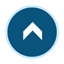](#contents)

<a id='annex'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:left; font-weight:regular; overflow:hidden"><strong>Annex • User upgrade strategies</strong></div>

The following is a list of **key actions** that can be taken **to get users to upgrade**, extracted from the "LinkedIn Advice" discussion:  
[_How can you persuade customers to upgrade to a premium version of your product?_](https://www.google.com/search?q=https://linkedin.com/advice/3/how-can-you-persuade-customers-upgrade-premium-oqeie)".  

> Strive to persuade customers, and they will feel manipulated and leave you.  
> **Reduce time to value and surprise them with outstanding experience, they will remain loyal and upgrade.**  
> Great services will keep customers. Ensure you delight them and they will have plenty of reasons to upgrade.
>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[**David Pereira**](https://www.linkedin.com/in/davidavpereira/?trk=article-ssr-frontend-x-article), Product Coach & Speaker

---

**General / Cross-Functional Strategies**  
* The **« who »** → Understand your customers  
* The **« who »** → Identify needs, pain points, usage patterns  
* The **« who »** → Segment based on behavior, demographics, readiness to upgrade  
* The **« who »** → Gather feedback through data analytics, surveys, interviews, usability testing  
* Value proposition → Articulate benefits and ROI  
* Value proposition → Focus on how the upgrade solve specific user problems or enhance their experience  
* Value proposition → Showcase  
* Communication → Tailor messaging and positioning to different user segments  
* Communication → Use clear, concise language  
* Communication → Communicate benefits, not just features  
* Upgrade paths → Make upgrade process seamless and intuitive  
* Upgrade paths → Provide in-app prompts and notifications  

**Product**
* Tiered pricing → Design increasing value for higher plans  
* Tiered pricing → Ensure a clear differentiation between tiers  
* Tiered pricing → Enable gating and trials  
* Limited-time trials → Gate advanced features behind the premium tier  
* Limited-time trials → Optimize user experience (UX)  
* Limited-time trials → Ensure the basic product provides core value to keep users engaged  
* Limited-time trials → Design smooth, intuitive upgrade flow  
* Usage-based value → If applicable, highlight how users are approaching plan limits  
* Usage-based value → Provide insights into potential benefits from increased limits or advanced features  

**Marketing**
* Targeted campaigns → Email, in-app messages, push notifications  
* Targeted campaigns → Use retargeting ads for users who have shown interest in premium features  
* Content marketing → Create case studies, testimonials, and success stories showcasing premium benefits  
* Content marketing → Develop educational content that demonstrates how premium features solve advanced problems  
* Promotional offers → Offer incentives for upgrading  
* Leverage social proof → Highlight the number of users already on premium plans or positive reviews  

**Sales / Customer Success**
* Proactive outreach → Identify power users or those hitting limits on free/basic plans and reach out with tailored upgrade offers
* Proactive outreach → Conduct business reviews with existing customers to identify growth opportunities  
* Education and support → Ensure customer support teams are knowledgeable about premium features and can articulate their value  
* Education and support → Provide training or onboarding for new premium features

<br>

[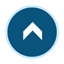](#contents)

<a id='wrapup'></a>

<div style="font-size:26px; background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:left; font-weight:regular; overflow:hidden"><strong>Wrap-up</strong></div>

<p style="font-size: 5rem;">🚧 Work in Progress</p>

[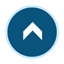](#contents)